### Verification and Training Errors



In [37]:
network_inf = 'nets/siren/0010_0015.pt'


In [38]:
'load the net set up for eval'
import torch
from Modules.Neural_Net import Net
model = torch.load(network_inf, weights_only=False)
scaler_in, scaler_out = model['scalers']

net = Net(torch.sin, *model['model config'])
net.load_state_dict(model['model_state_dict'])

net.to('cuda')
net.eval()


'done'

'done'

In [ ]:
import torch
import Modules.preprocess as pp
import numpy as np 
import re

step = 1

data  = torch.load('../../data/data.pt', weights_only=True)

nums = re.findall(r'\d+', network_inf)  
first, second = map(int, nums[:2]) 
frames = np.arange(first, second, step=step)

train_beams = list(range(0,32))

model = torch.load(network_inf, weights_only=False)

scaler_in, scaler_out = model['scalers']
masker = model['masker']

datasets = pp.data_gen(data, beams = train_beams, frames=frames, normalize=model['scalers'], masker = masker)
train_dataloader, ver_dataloader  = datasets.get_dataloaders(batch_size=1, num_workers=4)
 

In [42]:
import numpy as np
import torch

'Store frame error in list'
err_chunks = []

net.eval()
with torch.no_grad():
    for inputs, d in train_dataloader:
        inputs = inputs.cuda()


        d = d.view(-1, 1).cpu().numpy()
        d = scaler_out.inverse_transform(d)

        nn = net(inputs).view(-1, 1).cpu().numpy()
        nn = scaler_out.inverse_transform(nn)

       
        e = (d - nn) #signed distance between points
        err_chunks.append(e.ravel())

# get all points togethr
error = np.concatenate(err_chunks)

ver_err_chunks = []

with torch.no_grad():
    for inputs, vd in ver_dataloader:
        inputs = inputs.cuda()


        vd = vd.view(-1, 1).cpu().numpy()
        vd = scaler_out.inverse_transform(vd)

        preds_np = net(inputs).view(-1, 1).cpu().numpy()
        preds_np = scaler_out.inverse_transform(preds_np)

        err = (preds_np - vd) #signed distance between points
        ver_err_chunks.append(err.ravel())

ver_error =  np.concatenate(ver_err_chunks)



In [43]:
import matplotlib.pyplot as plt
import numpy as np

rms = round(np.sqrt(((error/.06)**2)).mean(),3)
vrms = round(np.sqrt(((ver_error/.06)**2)).mean(), 3)

print(rms, vrms)

2.448 2.519


In [44]:
r = 1

mask = (error <r) & (error> -r) 
vmask = (ver_error <r) & (ver_error> -r) 

r_e = error[mask]
r_ve = ver_error[vmask]

In [45]:
from scipy.stats import norm

mean = r_e.mean()
ver_mean = r_ve.mean()
std = r_e.std()
ver_std = r_ve.std()
xmin, xmax = [-r,r]
x = np.linspace(xmin, xmax, 200)
p = norm.pdf(x, loc = mean, scale = std)
ver_p = norm.pdf(x,  loc = ver_mean, scale = ver_std)

In [46]:
fs = mean
sec = np.mean(r_e**2)

print(ver_std /.06)

3.203408


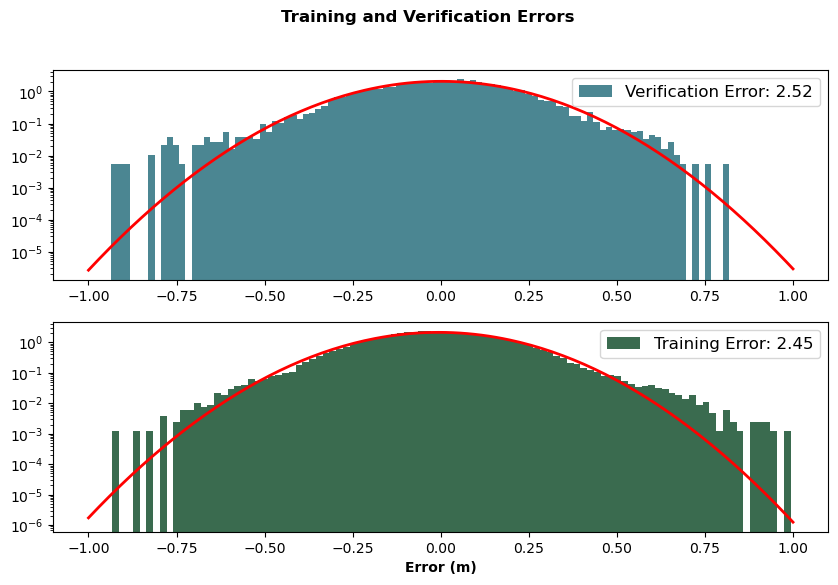

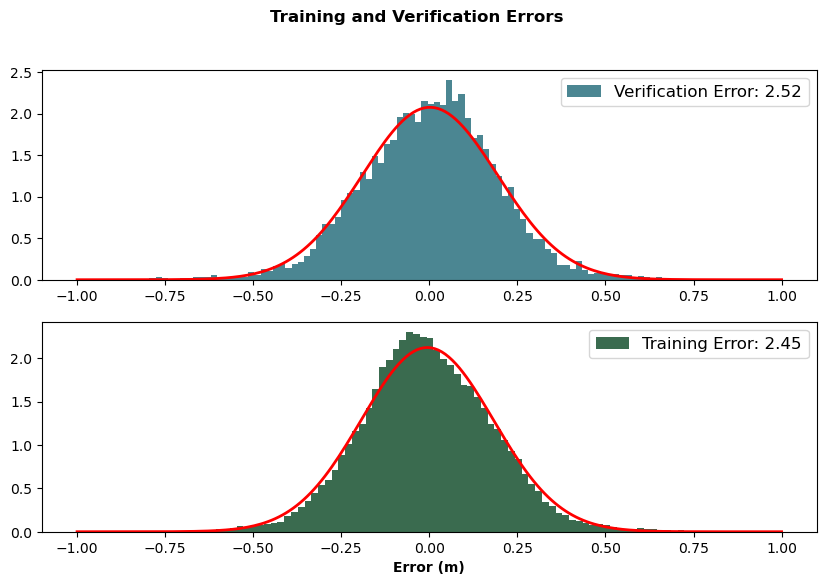

In [47]:
log = True
fig, (ax1, ax2) = plt.subplots(2, figsize = (10,6))

ax1.hist(r_ve, bins=100, log=log,
color = "#4b8692ff", label = f"Verification Error: {vrms:.2f}", density = True )  # count on log scale
ax2.hist(r_e, bins = 100, log = log,
color = "#3a6b4fff", label = f"Training Error: {rms:.2f}", density = True)

ax1.plot(x, ver_p, color= 'red', linewidth =2)
ax2.plot(x,p, color = 'red', linewidth =2)

# ax1.set_yscale('log')
# ax2.set_yscale('log')



ax1.legend(fontsize = 'large', loc = 'upper right')
ax2.legend(fontsize = 'large', loc = 'upper right')
ax2.set_xlabel("Error (m)", fontweight = 'bold')


plt.suptitle('Training and Verification Errors', fontweight = 'bold')
plt.show()

fig, (ax1, ax2) = plt.subplots(2, figsize = (10,6))

ax1.hist(r_ve, bins=100, log=not(log),
color = "#4b8692ff", label = f"Verification Error: {vrms:.2f}", density = True )  # count on log scale
ax2.hist(r_e, bins = 100, log = not(log),
color = "#3a6b4fff", label = f"Training Error: {rms:.2f}", density = True)

ax1.plot(x, ver_p, color= 'red', linewidth =2)
ax2.plot(x,p, color = 'red', linewidth =2)

# ax1.set_yscale('log')
# ax2.set_yscale('log')



ax1.legend(fontsize = 'large', loc = 'upper right')
ax2.legend(fontsize = 'large', loc = 'upper right')
ax2.set_xlabel("Error (m)", fontweight = 'bold')


plt.suptitle('Training and Verification Errors', fontweight = 'bold')
plt.show()

## Surface Discrepancy Plots

In [73]:
network1 = 'nets/siren/robust_300_320.pt'
network2 = 'nets/siren/second_300_320.pt'

In [74]:
def add_t(tensor, time):
    return torch.cat([tensor, torch.ones_like(tensor[:, 0]).unsqueeze(1)*time], dim=1).to(dtype=torch.float32)

In [75]:
from Modules.Neural_Net import Net
from Modules.evaluate import Evaluator


model1 = torch.load(network1, weights_only=False)
model2 = torch.load(network2, weights_only=False)

net1 = Net(torch.sin, *model1['model config'])
net2 = Net(torch.sin, *model2['model config'])

inputs = torch.load('Modules/plotting_region.pt', weights_only= True)

x = inputs[:, 0:1].cpu().detach().numpy()
y = inputs[:, 1:2].cpu().detach().numpy()

scaler1 = model1['scalers']
scaler2 = model2['scalers']

t = torch.linspace(30, 34, 50)

In [76]:
def get_diff(time):
    xyt = add_t(inputs, time)

    eval1 = Evaluator(net1, scaler1, xyt)
    eval2 = Evaluator(net2, scaler2, xyt)

    pred1 = eval1.net_eval()
    pred2 = eval2.net_eval()

    diff = -pred2 + pred1

    z = diff.cpu().detach().numpy()

    ad = round(z.mean(), 3)
    return z, ad


In [77]:
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

def plot(x,y, z, ad,i):
    fig, ax = plt.subplots(figsize = (9,4))
    sc = ax.scatter(x,y,c =z, cmap = cmc.vik, vmin = -.12, vmax =.12, label = f'Average Difference: {ad:.3f} (m)')
    cbar = fig.colorbar(sc, ax=ax, label = "meters")
    ax.legend()

    ax.set_xlim(-255, -133)
    ax.set_ylim(-180, -145)

    ax.set_xlabel('Cross Shore', fontweight = 'bold')
    ax.set_ylabel('Along Shore', fontweight = 'bold')
    ax.set_title(r'Difference of $\eta_1$ and $\eta_2$', fontsize = 12, fontweight = 'bold')

    plt.savefig(f'figures/difference/{i:04d}', dpi =300)

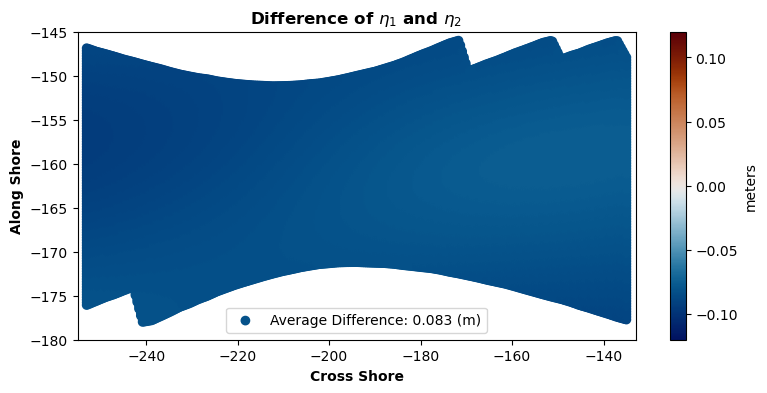

In [79]:
z, ad = get_diff(30.2)
plot(x,y,-z,ad,0)

C:\Users\dculv\AppData\Local\Temp\ipykernel_30280\2118099684.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize = (9,4))


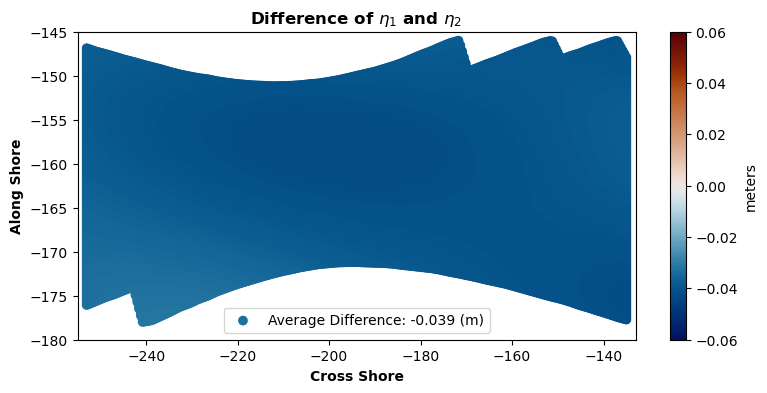

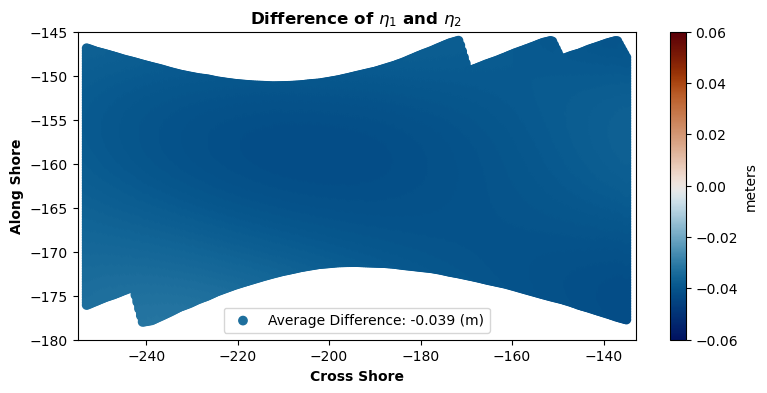

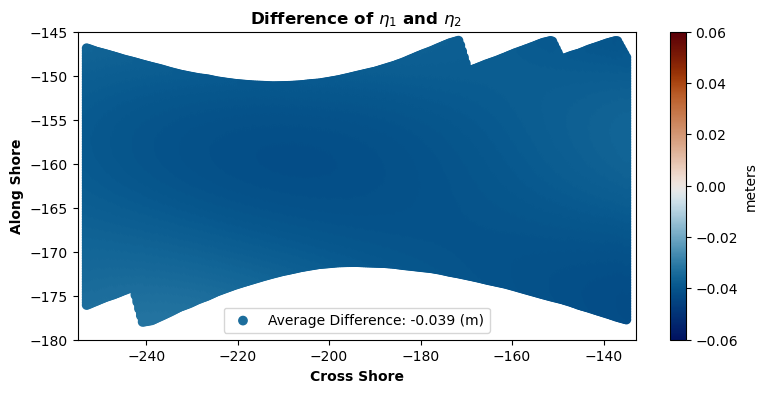

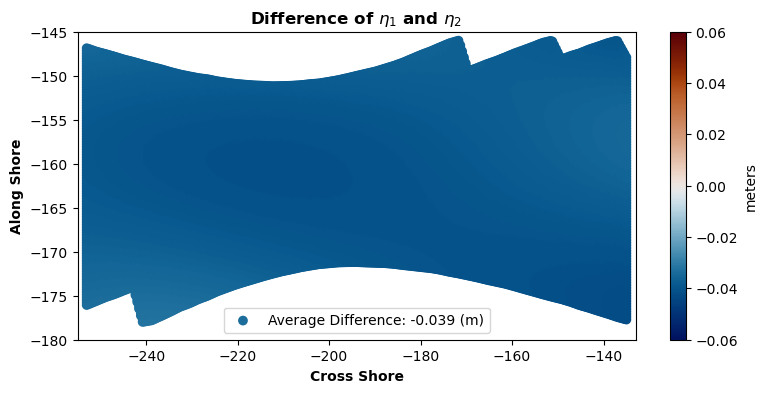

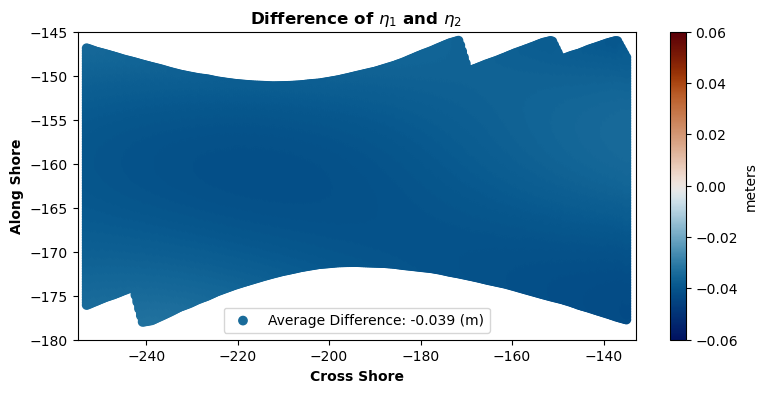

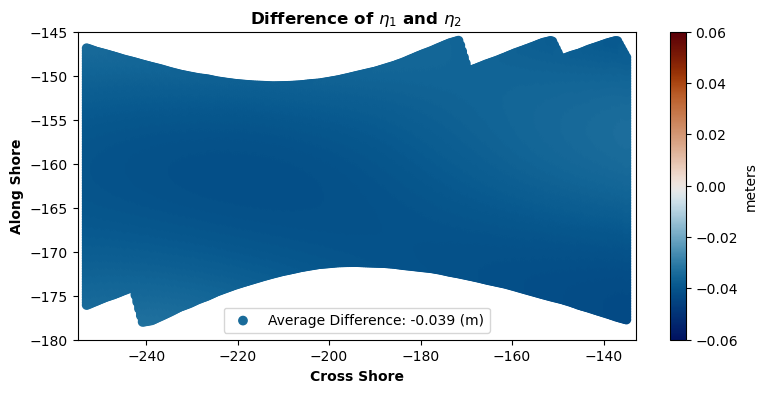

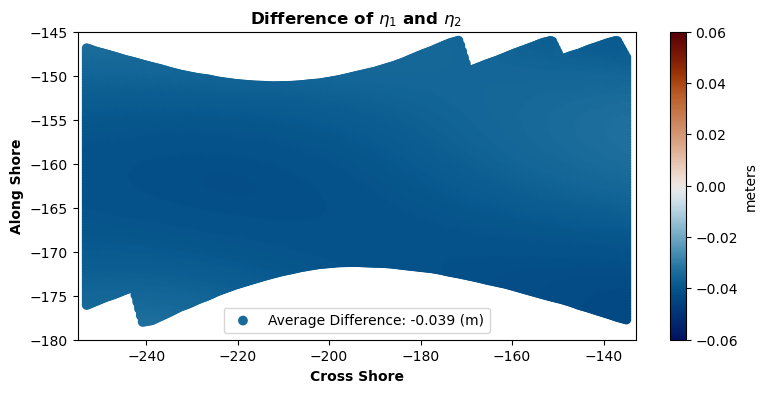

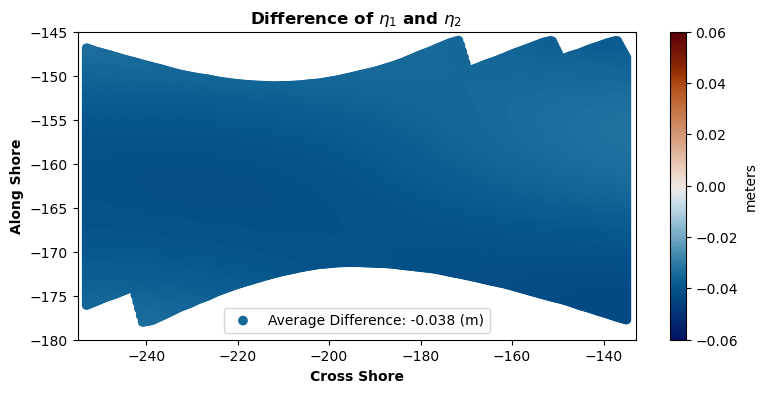

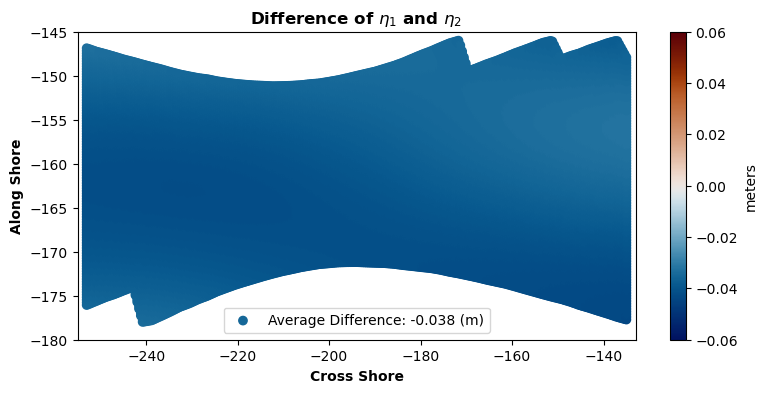

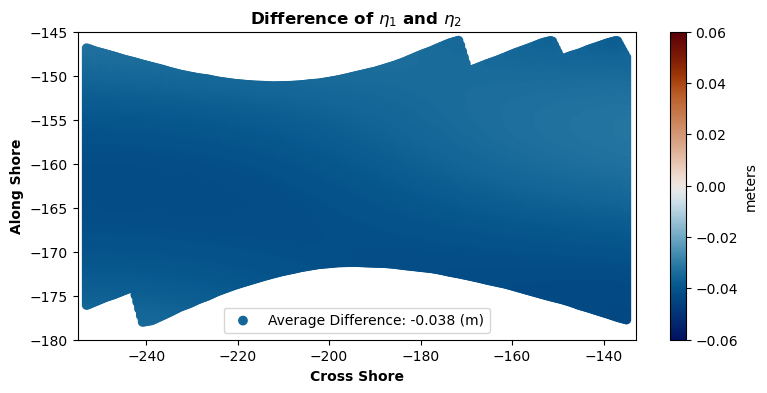

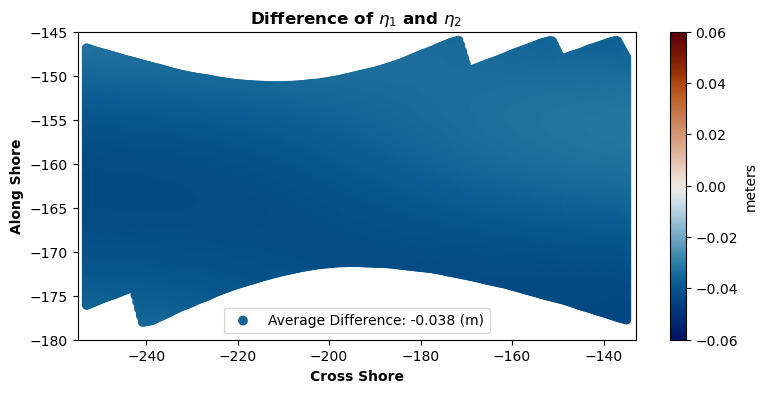

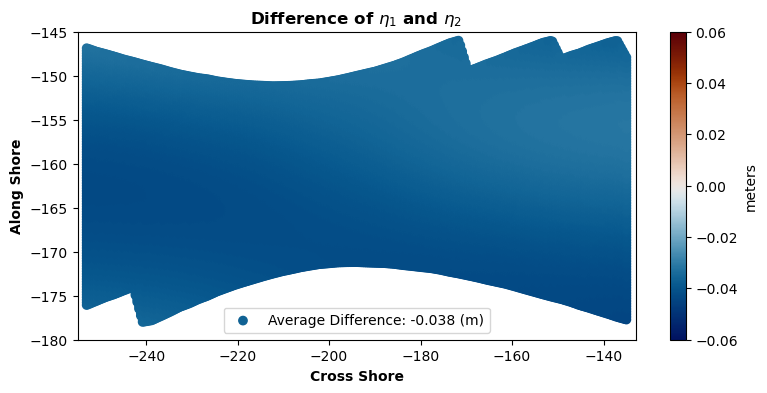

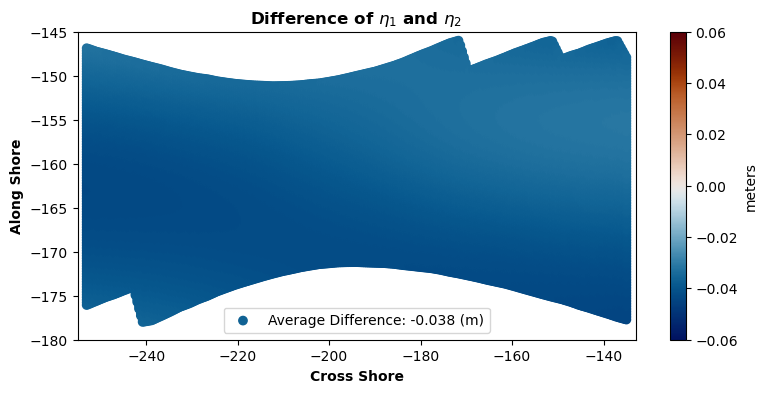

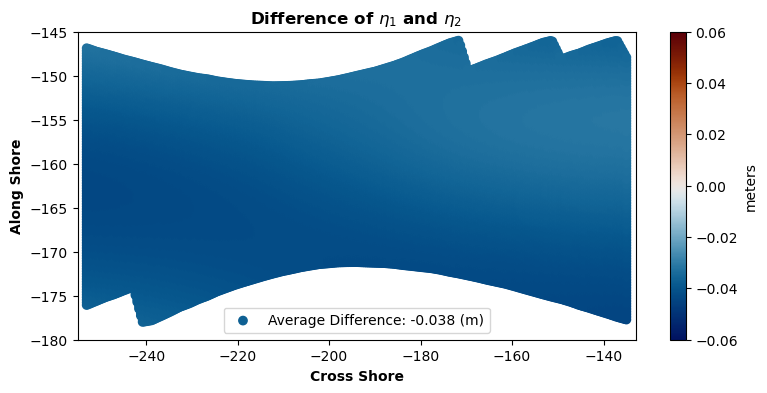

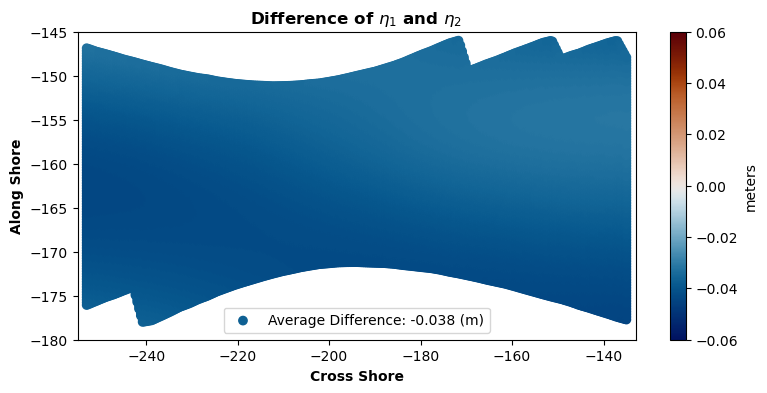

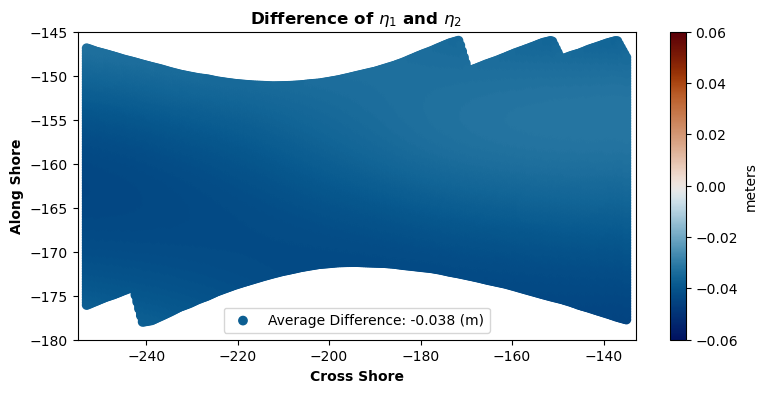

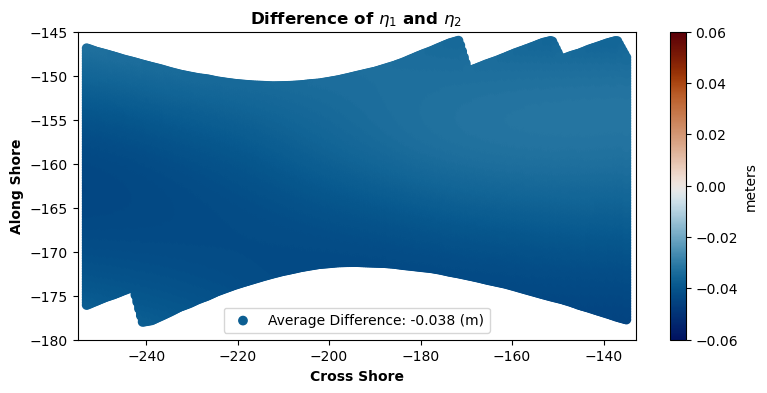

Error in callback <function flush_figures at 0x0000018149D7D580> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [22]:
for i, time in enumerate(t):
    z,ad = get_diff(time)
    plot(x,y,z,ad,i)

### Here we make plots of the training data vs validation data vs testing data

In [1]:
import torch
from Modules import pre_pro
from Modules.Neural_Net import Net
from Modules.Neural_Net import NetWrapper
from tqdm import tqdm
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import numpy as np
from torch.utils.data import DataLoader
import seaborn




### Training Data

In [2]:
'Iterate through dataloader taking rms errors.'


data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(250,350, 1)
device = 'cuda'

beams = list(range(6, 20))
indices_to_remove = [4, 30]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)

dataset = pre_pro.FrameDataset(input, output)
spt_dataloader = DataLoader(dataset, shuffle=True, batch_size=1)


In [3]:
network_info = torch.load('nets/SPT/spt_e_10000_a_5.pt', weights_only=True)
net = Net(torch.cos, *network_info['model config'])
net.load_state_dict(network_info['model_state_dict'])
net.to('cuda')

'hi'

'hi'

In [4]:
network_info = torch.load('nets/MSE/MSE_250_350.pt', weights_only=True)
mse_net = Net(torch.cos, *network_info['model config'])
mse_net.load_state_dict(network_info['model_state_dict'])
mse_net.to('cuda')

'hi'

'hi'

In [9]:
'error at each point in space and time'
stats = []

with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = net(batch_x)
        nrms = torch.sqrt(((pred_y - batch_y)/.06)**2).reshape(-1).cpu().numpy()
        stats.append(nrms)


mse_stats = []

with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = mse_net(batch_x)
        nrms = torch.sqrt(((pred_y - batch_y)/.06)**2).reshape(-1).cpu().numpy()
        mse_stats.append(nrms)


 Regulrized NRMS: 1.378644347190857, MSE NRMS: 1.4603949785232544


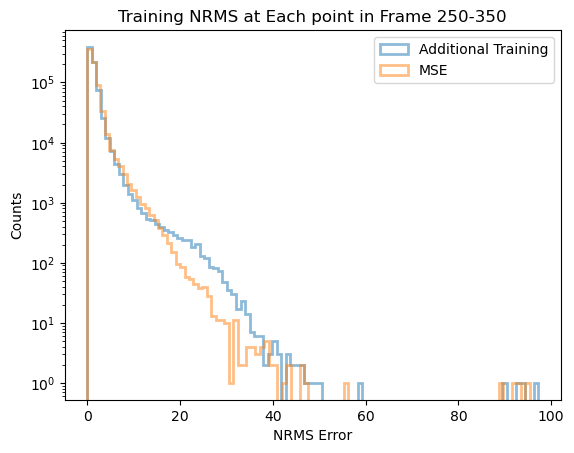

In [12]:
results = np.concatenate(stats)
mse_results = np.concatenate(mse_stats)

print(f' Regulrized NRMS: {results.mean()}, MSE NRMS: {mse_results.mean()}')

att = dict(histtype='step', linewidth = 2, alpha=0.5)
plt.hist(results, bins=100, **att, color='C0', label='Additional Training')
plt.hist(mse_results, bins=100, **att, color='C1', label='MSE')
plt.yscale('log')
plt.xlabel('NRMS Error')
plt.ylabel('Counts')
plt.title('Training NRMS at Each point in Frame 250-350')
plt.legend()
plt.show()

In [10]:
stats = []
k=0
with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = net(batch_x)
        nrms = torch.sqrt(torch.mean((pred_y - batch_y)**2)).item()*100
        stats.append(nrms)



In [5]:
avg_error = sum(stats)/len(stats)
print(f'Average RMS Error: {avg_error} cm')

Average RMS Error: 32.32579617202282 cm


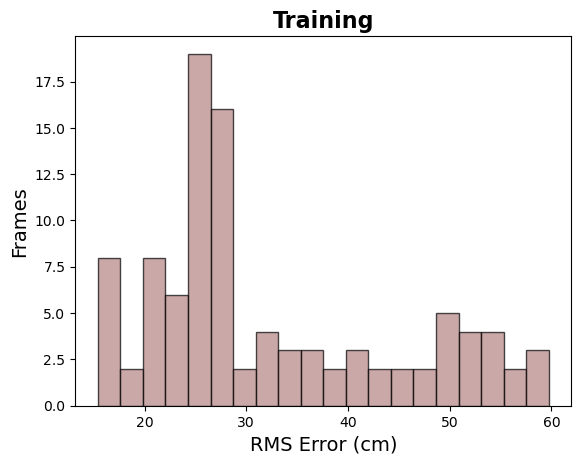

In [6]:
plt.hist(stats, bins=20, density=False, alpha=0.7, color="#B48383", edgecolor='black')
plt.xlabel('RMS Error (cm)', fontsize = 14)
plt.ylabel('Frames', fontsize = 14)
plt.title('Training', fontweight = 'bold', fontsize = 16)
plt.show()


## Testing

In [13]:
'Iterate through dataloader taking rms errors.'


data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(250,350, 1)
device = 'cuda'

beams =[4,30]
# indices_to_remove = [10, 11]
# beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)

dataset = pre_pro.FrameDataset(input, output)
spt_dataloader_test = DataLoader(dataset, shuffle=True, batch_size=1)


In [10]:
stats_test = []
k=0
with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader_test:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = net(batch_x)
        nrms = torch.sqrt(torch.mean((pred_y - batch_y)**2)).item()*100
        stats_test.append(nrms)


In [13]:
avg_error_test = sum(stats_test)/len(stats_test)
print(f'Average RMS Error (Test Beams): {avg_error_test} cm')

Average RMS Error (Test Beams): 31.46412968635559 cm


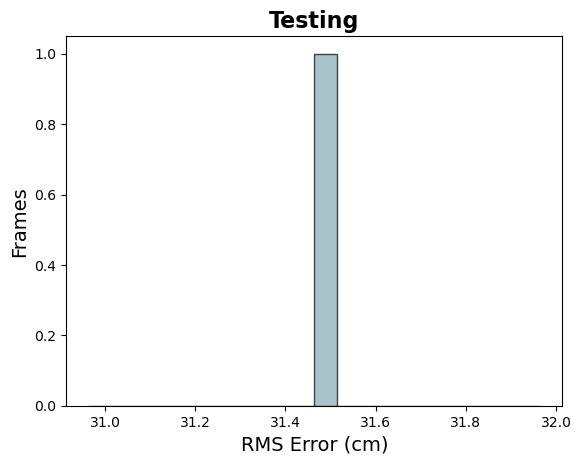

In [14]:
plt.hist(stats_test, bins=20, density=False, alpha=0.7, color="#83ACB4", edgecolor='black')
plt.xlabel('RMS Error (cm)', fontsize = 14)


plt.ylabel('Frames', fontsize = 14)

plt.title('Testing', fontweight = 'bold', fontsize = 16)
plt.show()

In [14]:
'one frame'


stats_test = []

with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader_test:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = net(batch_x)
        nrms = torch.sqrt(((pred_y - batch_y)/.06)**2).reshape(-1).cpu().numpy()
        stats_test.append(nrms)


mse_stats_test = []

with torch.no_grad():
    for (batch_x, batch_y) in spt_dataloader_test:
        batch_x = batch_x.to('cuda')
        batch_y = batch_y.to('cuda')
        pred_y = mse_net(batch_x)
        nrms = torch.sqrt(((pred_y - batch_y)/.06)**2).reshape(-1).cpu().numpy()
        mse_stats_test.append(nrms)


Regulirezed NRMS: 3.3633065223693848, MSE NRMS: 1.8125994205474854


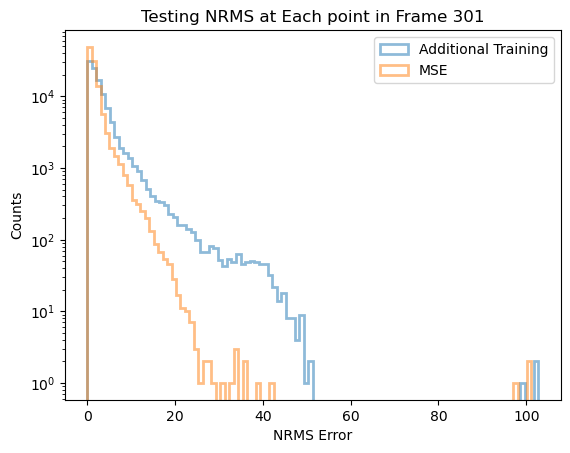

In [16]:
results = np.concatenate(stats_test)
mse_results = np.concatenate(mse_stats_test)

print(f'Regulirezed NRMS: {results.mean()}, MSE NRMS: {mse_results.mean()}')

att = dict(histtype='step', linewidth = 2, alpha=0.5)
plt.hist(results, bins=100, **att, color='C0', label='Additional Training')
plt.hist(mse_results, bins=100, **att, color='C1', label='MSE')
plt.yscale('log')
plt.xlabel('NRMS Error')
plt.ylabel('Counts')
plt.title('Testing NRMS at Each point in Frame 301')
plt.legend()
plt.show()